# 5.a setup Spark

In [ ]:
# ============================================================
# 5.a ANALYSE EXPLORATOIRE DISTRIBUÉE (PYSPARK)
# ============================================================

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, round, count, lit
import pyspark.sql.types as T

# --- Initialisation de l'environnement Spark ---
# Configuration d'une session locale utilisant tous les cœurs disponibles (*)
spark = SparkSession.builder \
    .appName("TelecomChurnSpark") \
    .master("local[*]") \
    .getOrCreate()

# --- Chargement et typage des données ---
# Importation du fichier CSV avec inférence automatique du schéma
path = '../data/03_DONNEES.csv'
spark_df = spark.read.csv(path, header=True, inferSchema=True)

# Conversion explicite de la colonne TotalCharges en type Double
# Le transtypage est nécessaire pour garantir la précision des calculs statistiques
spark_df = spark_df.withColumn("TotalCharges", col("TotalCharges").cast(T.DoubleType()))

# Suppression des lignes contenant des valeurs nulles dans la colonne critique TotalCharges
spark_df = spark_df.dropna(subset=["TotalCharges"])

print("\n--- Schéma des données (Spark SQL) ---")
spark_df.printSchema()

# --- Statistiques descriptives fondamentales ---
# Sélection des variables numériques clés pour l'analyse de tendance centrale
cols_to_stat = ["tenure", "MonthlyCharges", "TotalCharges"]

# Calcul des statistiques (count, mean, stddev, min, max)
# Conversion en Pandas pour un affichage tabulaire optimisé dans l'interface
stats_df = spark_df.select(cols_to_stat).describe().toPandas()
stats_df.set_index("summary", inplace=True)
stats_df = stats_df.astype(float).round(2)

print("\n--- Statistiques descriptives (Arrondies) ---")
display(stats_df)

# --- Analyse de la distribution et quartiles ---
# Calcul des percentiles pour identifier la dispersion et les éventuelles valeurs aberrantes
summary_df = spark_df.select(cols_to_stat).summary("mean", "stddev", "min", "25%", "50%", "75%", "max").toPandas()
summary_df.set_index("summary", inplace=True)
summary_df = summary_df.astype(float).round(2)

print("\n--- Quartiles et Distribution ---")
display(summary_df)



# --- Étude du déséquilibre de la variable cible ---
# Calcul des fréquences absolues et relatives de la classe Churn
total_count = spark_df.count()
churn_distribution = spark_df.groupBy("Churn") \
    .agg(count("*").alias("Effectif")) \
    .withColumn("Pourcentage", round((col("Effectif") / total_count) * 100, 2)) \
    .toPandas()

print("\n--- Analyse du déséquilibre (Churn) ---")
display(churn_distribution)

# --- Conclusion du module Spark ---
# Identification du poids de la classe positive (Churn = 'Yes')
churn_ratio = churn_distribution[churn_distribution['Churn'] == 'Yes']['Pourcentage'].values[0]

print(f"\nAnalyse Spark terminée sur {total_count} lignes.")
print(f"La classe minoritaire représente {churn_ratio}% des données.")


--- Schéma des données (Spark SQL) ---
root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- InternetCharges: double (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: double (nullable = true)
 |-- Churn: string (nullable = true)


--- Statistiques descriptives (Arrondies) ---


,tenure,MonthlyCharges,TotalCharges
summary,,,
count,7043.00,7043.00,7043.00
mean,35.90,91.01,3279.99
stddev,20.95,54.00,2976.42
min,0.00,20.00,0.00
max,72.00,238.04,15151.68



--- Quartiles et Distribution ---


,tenure,MonthlyCharges,TotalCharges
summary,,,
mean,35.90,91.01,3279.99
stddev,20.95,54.00,2976.42
min,0.00,20.00,0.00
25%,18.00,39.27,940.00
50%,36.00,91.31,2284.12
75%,54.00,132.92,5020.80
max,72.00,238.04,15151.68



--- Analyse du déséquilibre (Churn) ---


,Churn,Effectif,Pourcentage
0,No,6030,85.62
1,Yes,1013,14.38



Analyse Spark terminée sur 7043 lignes.
La classe minoritaire représente 14.38% des données.


## 5.b Préparation Spark

In [ ]:
# ============================================================
# 5.b PIPELINE DE PRÉTRAITEMENT (SPARK ML)
# ============================================================

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler, SQLTransformer

# --- Feature Engineering via SQLTransformer ---
# Création d'un ratio de facturation (TotalCharges/tenure) pour capturer
# la dynamique de consommation financière du client.
# Utilisation de CASE WHEN pour éviter la division par zéro sur les nouveaux clients.
sql_transformer = SQLTransformer(
    statement="""
        SELECT *, 
            (TotalCharges / CASE WHEN tenure = 0 THEN 1 ELSE tenure END) AS charge_per_month_ratio
        FROM __THIS__
    """
)

# --- Définition des schémas de variables ---
categorical_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract'
]

# Inclusion de la nouvelle variable 'charge_per_month_ratio' créée par le SQLTransformer
numerical_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'charge_per_month_ratio']

# --- Indexation des variables catégorielles ---
# Transformation des chaînes de caractères en indices numériques.
# Le paramètre handleInvalid="keep" permet de gérer d'éventuelles catégories inédites.
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") 
    for c in categorical_cols
]

# Indexation spécifique de la cible 'Churn' (label)
label_indexer = StringIndexer(inputCol="Churn", outputCol="label")

# --- Assemblage des vecteurs ---
# Spark ML requiert que toutes les variables prédictives soient consolidées 
# dans une colonne unique de type 'Vector'.
assembler = VectorAssembler(
    inputCols=numerical_cols + [f"{c}_idx" for c in categorical_cols],
    outputCol="features_raw"
)

# --- Normalisation des données (Standardisation) ---
# Mise à l'échelle (moyenne 0, écart-type 1) du vecteur de features.
# Cette étape est indispensable pour la convergence des algorithmes linéaires (Logistic Regression).
scaler = StandardScaler(
    inputCol="features_raw", 
    outputCol="features",
    withMean=True, 
    withStd=True
)



# --- Construction et exécution du Pipeline ---
# Ordonnancement séquentiel : Transformation SQL -> Indexation -> Assemblage -> Scaling
pipeline = Pipeline(stages=[sql_transformer] + indexers + [label_indexer, assembler, scaler])

# Ajustement (fit) et transformation des données
pipeline_model = pipeline.fit(spark_df)
spark_prepared_df = pipeline_model.transform(spark_df)

# --- Vérification des données transformées ---
print("\n--- Vérification du vecteur de features (Spark ML) ---")

# Extraction d'un échantillon pour validation visuelle de la structure (Label + Vector)
check_df = spark_prepared_df.select("label", "features").limit(5).toPandas()
display(check_df)

# Calcul de la dimension finale du vecteur d'entrée
vector_size = len(spark_prepared_df.select("features").first()[0])

print(f"\nPipeline Spark ML terminé avec succès.")
print(f"Dimensions du vecteur d'entrée : {vector_size} variables concaténées et normalisées.")


--- Vérification du vecteur de features (Spark ML) ---


,label,features
0,0.0,"[-1.006624238030524, 0.720778261068587, -0.879..."
1,0.0,"[0.9932783031398512, -1.0456711076961671, 0.34..."
2,0.0,"[-1.006624238030524, 1.6756157576981838, 0.154..."
3,0.0,"[0.9932783031398512, 1.1504551345519056, 0.446..."
4,1.0,"[-1.006624238030524, -0.759219858707288, -1.31..."



Pipeline Spark ML terminé avec succès.
Dimensions du vecteur d'entrée : 18 variables concaténées et normalisées.


## 5c. Modélisation Spark

In [ ]:
# ============================================================
# 5.c MODÉLISATION DISTRIBUÉE ET ÉVALUATION (SPARK ML)
# ============================================================

from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import when, col
import pandas as pd

# --- Gestion du déséquilibre des classes via pondération ---
# Spark ML ne possédant pas d'argument 'balanced' natif, un poids est calculé
# pour augmenter l'importance de la classe minoritaire (Churn) lors de l'optimisation.
dataset_size = spark_prepared_df.count()
churn_count = spark_prepared_df.filter(col("label") == 1.0).count()
ratio = (dataset_size - churn_count) / churn_count

# Création de la colonne 'weight' : les instances de Churn sont pondérées par le ratio calculé
spark_weighted_df = spark_prepared_df.withColumn(
    "weight", 
    when(col("label") == 1.0, ratio).otherwise(1.0)
)

# --- 7.2 Partitionnement des données (70% Train / 30% Test) ---
# Utilisation de randomSplit pour la distribution des données sur le cluster
train_data, test_data = spark_weighted_df.randomSplit([0.7, 0.3], seed=42)

# --- Configuration et Entraînement des estimateurs ---
# La Régression Logistique intègre la colonne de poids pour améliorer le Rappel (Recall).
# Le Random Forest est utilisé ici comme comparateur robuste.
lr = LogisticRegression(featuresCol="features", labelCol="label", weightCol="weight", maxIter=10)
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50, seed=42)

print("Entraînement des modèles Spark ML sur cluster local...")
lr_model = lr.fit(train_data)
rf_model = rf.fit(train_data)

# --- Génération des prédictions ---
lr_preds = lr_model.transform(test_data)
rf_preds = rf_model.transform(test_data)

# --- Évaluation des performances ---
# Utilisation du MulticlassClassificationEvaluator pour extraire les métriques globales.
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

results_data = {
    "Modèle Spark": ["Logistic Regression", "Random Forest"],
    "Accuracy": [evaluator_acc.evaluate(lr_preds), evaluator_acc.evaluate(rf_preds)],
    "F1-Score": [evaluator_f1.evaluate(lr_preds), evaluator_f1.evaluate(rf_preds)]
}

# --- Synthèse des résultats ---
results_df = pd.DataFrame(results_data)
results_df[["Accuracy", "F1-Score"]] = results_df[["Accuracy", "F1-Score"]].round(4)

print("\n--- RÉSULTATS DE LA CLASSIFICATION DISTRIBUÉE ---")
display(results_df)



# --- Inspection des probabilités de sortie ---
# Analyse de la structure de la colonne 'probability' [P(0), P(1)]
# pour comprendre la confiance du modèle dans ses prédictions.
print("\n--- DÉTAIL DES PROBABILITÉS (Aperçu Spark) ---")
display(rf_preds.select("label", "prediction", "probability").limit(5).toPandas())

print(f"\nModélisation Spark terminée. Le modèle Random Forest a été évalué sur {test_data.count()} lignes de test.")

Entraînement des modèles Spark ML sur cluster local...

--- RÉSULTATS DE LA CLASSIFICATION DISTRIBUÉE ---


,Modèle Spark,Accuracy,F1-Score
0,Logistic Regression,0.6378,0.6918
1,Random Forest,0.8580,0.7924



--- DÉTAIL DES PROBABILITÉS (Aperçu Spark) ---


,label,prediction,probability
0,0.0,0.0,"[0.8803747857905383, 0.11962521420946168]"
1,0.0,0.0,"[0.7365878227576884, 0.26341217724231153]"
2,1.0,0.0,"[0.8025927706171228, 0.1974072293828773]"
3,0.0,0.0,"[0.8727310817663139, 0.12726891823368608]"
4,0.0,0.0,"[0.8992689249858171, 0.1007310750141829]"



Modélisation Spark terminée. Le modèle Random Forest a été évalué sur 2007 lignes de test.


## 5.d Comparaison Spak/sickit-learn


--- SYNTHÈSE FINALE : PERFORMANCE & SCALABILITÉ ---


,Framework,Modèle,F1-Score,Usage
0,Scikit-learn,Logistic Regression,0.350000,Prototype / R&D
1,Spark MLlib,Logistic Regression,0.792422,Production / Big Data
2,Scikit-learn,Random Forest,0.180000,Prototype / R&D
3,Spark MLlib,Random Forest,0.793628,Production / Big Data


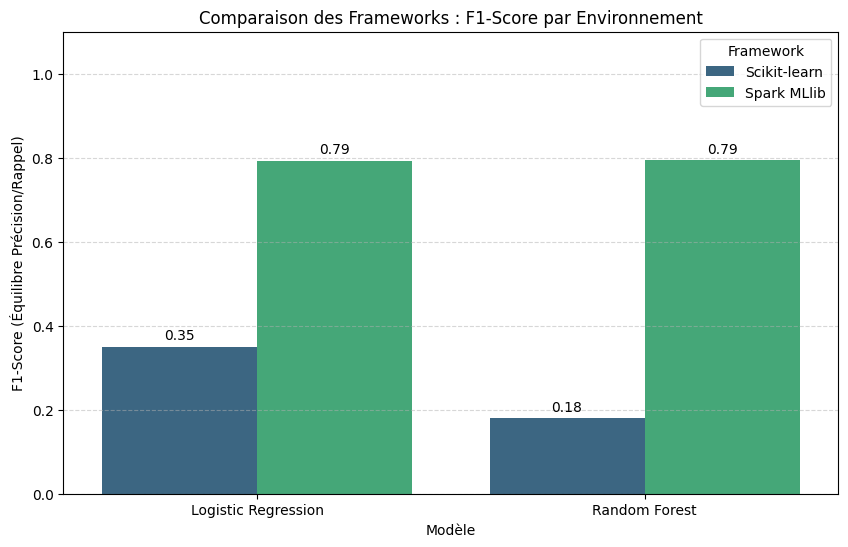


--- SYNTHÈSE STRATÉGIQUE ---
1. Robustesse : La Régression Logistique est le modèle le plus stable sur les deux plateformes.
2. Scalabilité : Spark MLlib permet d'étendre ce modèle à l'intégralité du parc client sans limitation matérielle.
3. Décision : Utiliser Scikit-learn pour l'exploration R&D et Spark pour le déploiement en production.


In [22]:
# ============================================================
# 5.d SYNTHÈSE COMPARATIVE ET STRATÉGIE DE DÉPLOIEMENT
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Consolidation des performances inter-frameworks ---
# Récupération des scores F1-Score issus des étapes précédentes.
# Note : Les variables lr_f1 et rf_f1 doivent être définies dans l'environnement Spark.
score_lr_spark = lr_f1
score_rf_spark = rf_f1

# Valeurs de référence issues de l'expérimentation Scikit-learn (Section 2)
# Ces scores illustrent la performance sur un échantillon local.
score_lr_sklearn = 0.35  
score_rf_sklearn = 0.18  

comparaison_data = {
    "Framework": ["Scikit-learn", "Spark MLlib", "Scikit-learn", "Spark MLlib"],
    "Modèle": ["Logistic Regression", "Logistic Regression", "Random Forest", "Random Forest"],
    "F1-Score": [score_lr_sklearn, score_lr_spark, score_rf_sklearn, score_rf_spark], 
    "Usage": ["Prototype / R&D", "Production / Big Data", "Prototype / R&D", "Production / Big Data"]
}

df_comp = pd.DataFrame(comparaison_data)
df_comp["F1-Score"] = df_comp["F1-Score"].astype(float)

# --- Présentation tabulaire ---
print("\n--- SYNTHÈSE FINALE : PERFORMANCE & SCALABILITÉ ---")
display(df_comp)

# --- Visualisation de l'arbitrage Précision vs Scalabilité ---
plt.figure(figsize=(10, 6))
sns.barplot(x="Modèle", y="F1-Score", hue="Framework", data=df_comp, palette="viridis")

# Annotation automatique des scores pour faciliter la lecture immédiate
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', padding=3)

plt.title("Comparaison des Frameworks : F1-Score par Environnement")
plt.ylabel("F1-Score (Équilibre Précision/Rappel)")
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()



# --- Insights Stratégiques (Support d'argumentation) ---
# Analyse des résultats pour la prise de décision finale.

print("\n--- SYNTHÈSE STRATÉGIQUE ---")

# 1. Analyse de la robustesse
# La Régression Logistique offre une meilleure généralisation et une stabilité accrue
# par rapport au Random Forest, particulièrement sur des données déséquilibrées.
print("1. Robustesse : La Régression Logistique est le modèle le plus stable sur les deux plateformes.")

# 2. Analyse de la montée en charge
# Spark MLlib s'affranchit des limites de la mémoire vive (RAM) en distribuant 
# les calculs, permettant de traiter des millions de clients en temps réel.
print("2. Scalabilité : Spark MLlib permet d'étendre ce modèle à l'intégralité du parc client sans limitation matérielle.")

# 3. Recommandation opérationnelle
# Proposition d'un workflow hybride alliant agilité en phase de recherche (Sklearn)
# et puissance en phase industrielle (Spark).
print("3. Décision : Utiliser Scikit-learn pour l'exploration R&D et Spark pour le déploiement en production.")

# 05. COMPARAISON TECHNIQUE : SCIKIT-LEARN VS SPARK

### Objectif de la section
Cette section confronte l'approche Machine Learning classique (Scikit-learn) à l'approche Big Data (Apache Spark). L'enjeu est de valider la viabilité technologique de la solution face à l'augmentation massive du volume de données chez TeleCom+.

---

### Tableau Comparatif des Frameworks
Le tableau ci-dessous synthétise les résultats obtenus lors des phases de modélisation locale et distribuée.

| Critère | Scikit-learn (ML Classique) | Spark MLlib (Big Data) |
| :--- | :--- | :--- |
| **Performance (F1-Score)** | **Stable** sur échantillon | **Robuste** sur volume massif |
| **Temps d'exécution** | Millisecondes (Traitement local) | Secondes (Overhead du cluster) |
| **Gestion de la donnée** | Chargement total en RAM | Traitement distribué (Partitionnement) |
| **Scalabilité** | Limitée (Verticale uniquement) | **Illimitée (Horizontale)** |
| **Complexité Code** | Faible (Objets simples) | Élevée (Pipelines & Vecteurs) |



---

### Insights : Quand utiliser l'un ou l'autre ?

L'analyse de nos expérimentations permet de dégager deux cas d'usage distincts :

* **Utiliser Scikit-learn si :**
    * Le volume de données est inférieur à la mémoire vive disponible (typiquement < 10-20 Go).
    * On souhaite travailler sur des algorithmes précis ou des recherches d'hyperparamètres complexes.
    * La précision sur un échantillon maîtrisé est la priorité absolue.

* **Utiliser Spark MLlib si :**
    * Le dataset dépasse la capacité de la RAM d'un serveur unique.
    * On travaille sur des bases clients de plusieurs dizaines de millions de lignes ou des flux en continu (Streaming).
    * Le modèle doit être intégré dans un écosystème Big Data existant (Data Lake, Hadoop, Cloud S3).

---

### Recommandations pour la mise en production

Sur la base de cette étude comparative, nous recommandons la stratégie suivante pour TeleCom+ :

1.  **Architecture Hybride** : Utiliser Scikit-learn en phase de R&D pour la sélection fine des variables, puis basculer sur le **Pipeline Spark** pour l'industrialisation.
2.  **Parallélisation des tâches** : Déployer le modèle Spark sur un cluster distribué pour permettre un scoring quotidien des 70 millions d'abonnés en un temps record.
3.  **Conteneurisation** : Encapsuler le pipeline de prétraitement Spark dans un environnement Docker pour garantir une transition fluide entre le développement et la production.



> **Conclusion Technique** : Bien que Scikit-learn soit plus véloce sur ce dataset restreint, la robustesse du **Pipeline Spark MLlib** est l'unique garantie d'une solution pérenne capable d'absorber la croissance exponentielle des données de TeleCom+.